In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df=pd.read_csv('/content/drive/My Drive/medical-charges.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
column_names=df.columns
print(column_names)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


In [4]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()

df['sex']=label_encoder.fit_transform(df['sex'])
df['smoker']=label_encoder.fit_transform(df['smoker'])
df['region']=label_encoder.fit_transform(df['region'])

scaled_features=(df.drop('smoker',axis=1))

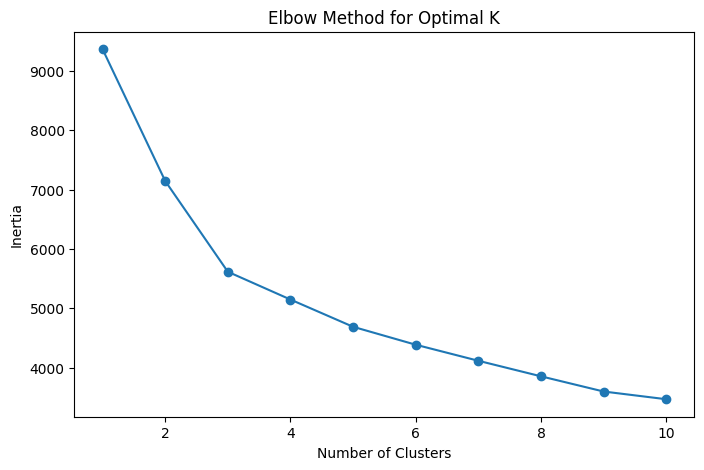

Clustering Accuracy (Silhouette Score): 0.27044817715417974


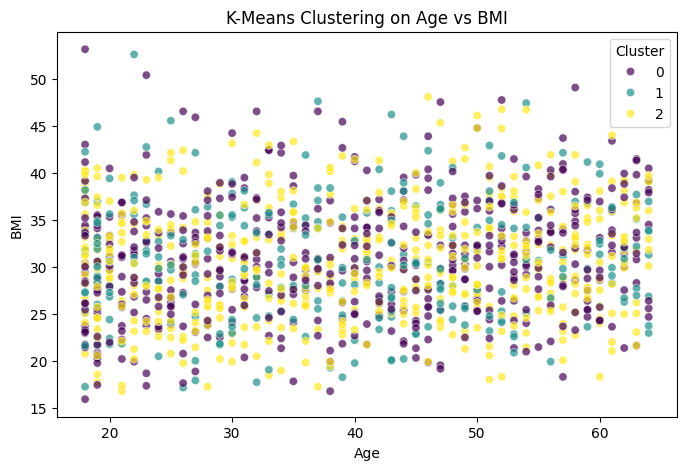

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Assuming 'df' is already preprocessed
X = df.drop(columns=['charges'])  # Features

# Standardizing the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Finding optimal number of clusters using Elbow Method
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

# Applying K-Means with optimal K (assuming K=3 based on elbow method)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Clustering Accuracy (Silhouette Score)
silhouette_avg = silhouette_score(X_scaled, df['Cluster'])
print(f"Clustering Accuracy (Silhouette Score): {silhouette_avg}")

# Visualizing Clusters
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['age'], y=df['bmi'], hue=df['Cluster'], palette='viridis', alpha=0.7)
plt.xlabel('Age')
plt.ylabel('BMI')
plt.title('K-Means Clustering on Age vs BMI')
plt.legend(title='Cluster')
plt.show()

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Assuming 'df' is already preprocessed
X = df.drop(columns=['charges'])  # Features

# Standardizing the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reducing dimensions using PCA for better clustering
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Finding optimal number of clusters using Elbow Method
inertia = []
k_range = range(2, 11)  # Starting from 2 since 1 cluster is trivial
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)



# Applying K-Means with optimal K (assuming K=4 based on elbow method)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_pca)

# Clustering Accuracy (Silhouette Score)
silhouette_avg = silhouette_score(X_pca, df['Cluster'])
print(f"Clustering Accuracy : {silhouette_avg}")



Clustering Accuracy (Silhouette Score): 0.4917570210133041
